# Projet Smart Grid — Analyse Exploratoire des Données (EDA)
### London Smart Meters — Étape 1 du projet

Groupe Jour 2 — Équipe 1 : Alpha Mamadou Douah BARRY, Khalilou Yacouba TANDIA, Ndeye Sophie MBAYE, Issiaka TRAORE


## 0. Setup et chargement des données

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
RANDOM_STATE = 42


In [2]:
HHBLOCK_DIR = "data/hhblock_dataset/hhblock_dataset"

block_files = sorted([f for f in os.listdir(HHBLOCK_DIR) if f.endswith(".csv")])
print(f"{len(block_files)} fichiers block_*.csv trouvés")

dfs = [pd.read_csv(os.path.join(HHBLOCK_DIR, f)) for f in block_files]
df_hh = pd.concat(dfs, ignore_index=True)

df_hh["day"] = pd.to_datetime(df_hh["day"])
hh_cols = [f"hh_{i}" for i in range(48)]

print("Shape :", df_hh.shape)
print("Période :", df_hh["day"].min(), "->", df_hh["day"].max())
print("Foyers uniques :", df_hh["LCLid"].nunique())
df_hh.head()


112 fichiers block_*.csv trouvés
Shape : (3469352, 50)
Période : 2011-11-24 00:00:00 -> 2014-02-27 00:00:00
Foyers uniques : 5560


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [3]:
df_info = pd.read_csv("data/informations_households.csv")
df_weather = pd.read_csv("data/weather_daily_darksky.csv")
df_bh = pd.read_csv("data/uk_bank_holidays.csv")

df_weather["time"] = pd.to_datetime(df_weather["time"])
df_bh["Bank holidays"] = pd.to_datetime(df_bh["Bank holidays"])

print(df_info.shape, df_weather.shape, df_bh.shape)


(5566, 5) (882, 32) (25, 2)


## 1. Volumétrie, qualité et carte des valeurs manquantes

In [4]:
# Nombre de jours DISTINCTS par foyer et par mois
df_hh["year_month"] = df_hh["day"].dt.to_period("M")
jours_par_foyer_mois = df_hh.groupby(["LCLid", "year_month"])["day"].nunique().unstack(fill_value=0)

print("Shape (foyers x mois) :", jours_par_foyer_mois.shape)
jours_par_foyer_mois.head()


Shape (foyers x mois) : (5560, 28)


year_month,2011-11,2011-12,2012-01,2012-02,2012-03,2012-04,2012-05,2012-06,2012-07,2012-08,...,2013-05,2013-06,2013-07,2013-08,2013-09,2013-10,2013-11,2013-12,2014-01,2014-02
LCLid,,,,,,,,,,,,,,,,,,,,,
MAC000002,0,0,0,0,0,0,0,0,0,0,...,31,30,31,31,30,31,30,31,30,27
MAC000003,0,0,0,9,31,30,30,30,31,31,...,30,30,31,31,30,31,30,31,31,27
MAC000004,0,0,0,0,0,0,23,28,31,31,...,30,30,31,31,30,31,30,31,31,27
MAC000005,0,0,0,0,0,0,0,27,30,31,...,31,30,31,31,30,31,30,31,31,27
MAC000006,0,0,1,29,31,30,30,30,31,31,...,31,30,31,31,30,31,30,31,31,27


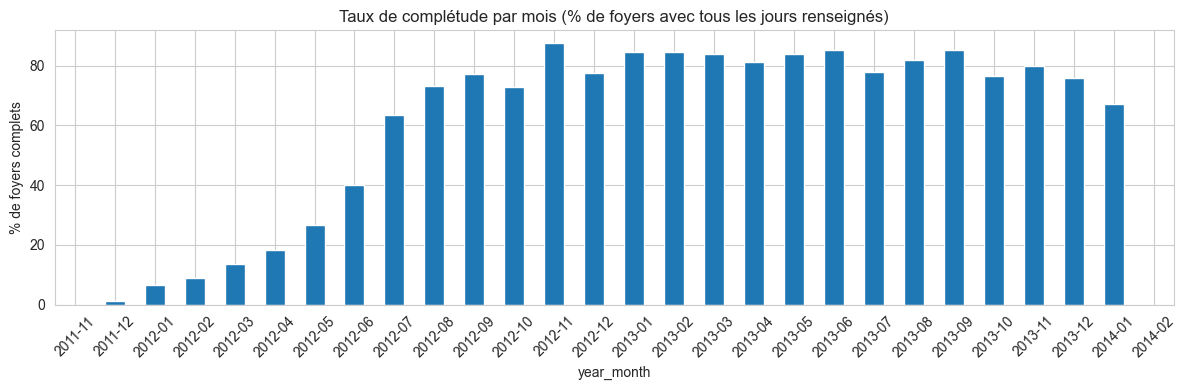

In [5]:
# Taux de complétude par mois : nombre attendu de jours dans chaque mois
nb_jours_calendaire = {col: col.days_in_month for col in jours_par_foyer_mois.columns}

taux_completude = jours_par_foyer_mois.copy()
for col in taux_completude.columns:
    taux_completude[col] = taux_completude[col] / nb_jours_calendaire[col]

completude_moyenne_par_mois = (taux_completude == 1.0).mean() * 100

plt.figure(figsize=(12, 4))
completude_moyenne_par_mois.plot(kind="bar")
plt.ylabel("% de foyers complets")
plt.title("Taux de complétude par mois (% de foyers avec tous les jours renseignés)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


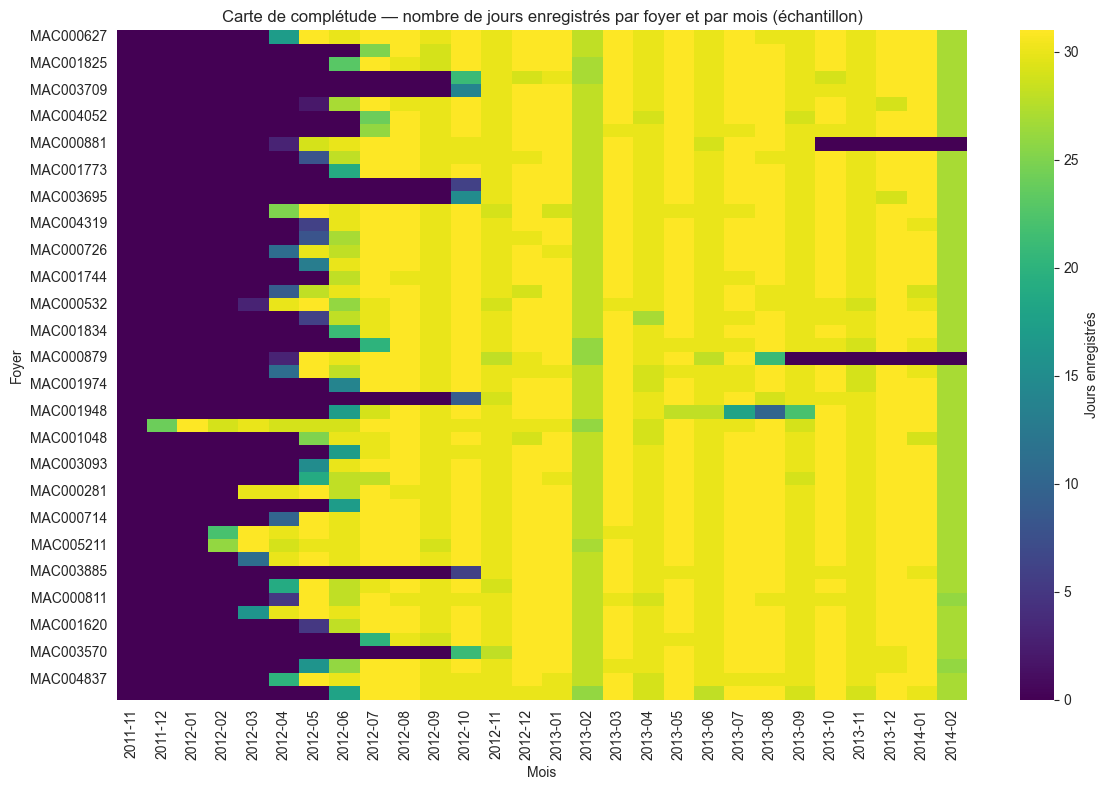

In [6]:
# Carte des valeurs manquantes : heatmap foyers x mois (échantillon de 50 foyers pour la lisibilité)
plt.figure(figsize=(12, 8))
echantillon = jours_par_foyer_mois.sample(min(50, jours_par_foyer_mois.shape[0]), random_state=RANDOM_STATE)
sns.heatmap(echantillon, cmap="viridis", cbar_kws={"label": "Jours enregistrés"})
plt.title("Carte de complétude — nombre de jours enregistrés par foyer et par mois (échantillon)")
plt.xlabel("Mois")
plt.ylabel("Foyer")
plt.tight_layout()
plt.show()


In [7]:
# Résumé chiffré global
print(f"Nombre total de foyers : {df_hh['LCLid'].nunique()}")
print(f"Nombre de mois couverts : {df_hh['year_month'].nunique()}")
print(f"Nombre total de lignes (foyer x jour) : {df_hh.shape[0]}")

# Valeurs manquantes et aberrantes dans les 48 colonnes horaires
print(f"\nValeurs manquantes (NaN) dans hh_0..hh_47 : {df_hh[hh_cols].isna().sum().sum()}")
print(f"Valeurs négatives : {(df_hh[hh_cols] < 0).sum().sum()}")


Nombre total de foyers : 5560
Nombre de mois couverts : 28
Nombre total de lignes (foyer x jour) : 3469352

Valeurs manquantes (NaN) dans hh_0..hh_47 : 5486
Valeurs négatives : 0


## 2. Distributions et valeurs aberrantes

In [10]:
# Distribution des consommations DEMI-HORAIRES (toutes les valeurs hh_0..hh_47 confondues)
n_lignes_echantillon = min(200_000, df_hh.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
indices_echantillon = rng.choice(df_hh.index, size=n_lignes_echantillon, replace=False)

# .loc[lignes, colonnes] : sélection combinée, pandas ne copie QUE ce sous-ensemble
echantillon_hist = df_hh.loc[indices_echantillon, hh_cols].to_numpy().flatten()

plt.figure(figsize=(10, 4))
sns.histplot(echantillon_hist, bins=60)
plt.xlabel("Consommation (kWh / demi-heure)")
plt.title(f"Distribution des consommations demi-horaires (échantillon de {n_lignes_echantillon:,} lignes)")
plt.tight_layout()
plt.show()

MemoryError: Unable to allocate 1.24 GiB for an array with shape (48, 3469352) and data type float64

In [ ]:
# Consommation QUOTIDIENNE totale par foyer x jour (somme des 48 valeurs)
df_hh["conso_jour"] = df_hh[hh_cols].sum(axis=1)

plt.figure(figsize=(10, 4))
sns.histplot(df_hh["conso_jour"], bins=60)
plt.xlabel("Consommation quotidienne totale (kWh)")
plt.title("Distribution de la consommation quotidienne (foyer x jour)")
plt.tight_layout()
plt.show()


In [ ]:
# Boxplot pour repérer les valeurs aberrantes
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_hh["conso_jour"])
plt.xlabel("Consommation quotidienne totale (kWh)")
plt.title("Boxplot — consommation quotidienne")
plt.tight_layout()
plt.show()


In [ ]:
# Détection des outliers par la méthode IQR (interquartile range)
q1 = df_hh["conso_jour"].quantile(0.25)
q3 = df_hh["conso_jour"].quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr

outliers = df_hh[(df_hh["conso_jour"] < borne_basse) | (df_hh["conso_jour"] > borne_haute)]

print(f"Bornes IQR : [{borne_basse:.2f}, {borne_haute:.2f}] kWh")
print(f"Nombre de jours-foyers aberrants : {outliers.shape[0]} ({100*outliers.shape[0]/df_hh.shape[0]:.2f}%)")


## 3. Courbes de charge moyennes — globale, par jour de semaine, par mois

In [ ]:
# Courbe moyenne GLOBALE (toutes mesures, tous foyers, toute la période)
courbe_globale = df_hh[hh_cols].mean()
heures = np.arange(48) / 2

plt.figure(figsize=(10, 4))
plt.plot(heures, courbe_globale.values)
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne globale")
plt.tight_layout()
plt.show()


In [ ]:
# Courbe moyenne par jour de la semaine (0=lundi ... 6=dimanche)
df_hh["jour_semaine"] = df_hh["day"].dt.dayofweek
courbes_par_jour = df_hh.groupby("jour_semaine")[hh_cols].mean()

noms_jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

plt.figure(figsize=(11, 5))
for j in range(7):
    plt.plot(heures, courbes_par_jour.loc[j], label=noms_jours[j])
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne par jour de la semaine")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Courbe moyenne par mois
df_hh["mois"] = df_hh["day"].dt.month
courbes_par_mois = df_hh.groupby("mois")[hh_cols].mean()

plt.figure(figsize=(11, 5))
for m in sorted(df_hh["mois"].unique()):
    plt.plot(heures, courbes_par_mois.loc[m], label=f"Mois {m}")
plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne par mois")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Effet météo — corrélation conso / température

In [ ]:
# Température moyenne quotidienne (moyenne de max et min)
df_weather["day_norm"] = df_weather["time"].dt.normalize()
df_weather["temp_moyenne"] = (df_weather["temperatureMax"] + df_weather["temperatureMin"]) / 2
df_weather_small = df_weather[["day_norm", "temp_moyenne"]]

df_hh["day_norm"] = df_hh["day"].dt.normalize()
merged_meteo = df_hh.merge(df_weather_small, on="day_norm", how="left")

print("Lignes sans température après jointure :", merged_meteo["temp_moyenne"].isna().sum())


In [ ]:
# Corrélation GLOBALE conso quotidienne / température
correlation_globale = merged_meteo["conso_jour"].corr(merged_meteo["temp_moyenne"])
print(f"Corrélation globale conso-température : {correlation_globale:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(merged_meteo["temp_moyenne"], merged_meteo["conso_jour"], alpha=0.1, s=10)
plt.xlabel("Température moyenne du jour (°C)")
plt.ylabel("Consommation quotidienne (kWh)")
plt.title(f"Consommation vs température (r={correlation_globale:.3f})")
plt.tight_layout()
plt.show()


In [ ]:
# Corrélation conso-température PAR FOYER (identifie les foyers "chauffage électrique")
def correlation_conso_temp(groupe):
    return groupe["conso_jour"].corr(groupe["temp_moyenne"])

correlations_par_foyer = merged_meteo.groupby("LCLid").apply(correlation_conso_temp)

print(correlations_par_foyer.describe())


In [ ]:
# On identifie les foyers avec une anti-corrélation marquée (conso monte quand temp baisse)
SEUIL_CHAUFFAGE = -0.3
foyers_chauffage = correlations_par_foyer[correlations_par_foyer < SEUIL_CHAUFFAGE]

print(f"Foyers avec forte anti-corrélation température (r < {SEUIL_CHAUFFAGE}) : {len(foyers_chauffage)}")
print(f"Soit {100*len(foyers_chauffage)/len(correlations_par_foyer):.1f}% des foyers")

plt.figure(figsize=(9, 4))
sns.histplot(correlations_par_foyer, bins=40)
plt.axvline(SEUIL_CHAUFFAGE, color="red", linestyle="--", label=f"Seuil ({SEUIL_CHAUFFAGE})")
plt.xlabel("Corrélation conso-température par foyer")
plt.title("Distribution des corrélations conso-température (repère les foyers 'chauffage électrique')")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Effet calendrier — semaine / week-end / jours fériés

In [ ]:
# Classification de chaque jour : semaine, week-end, ou férié (le férié est prioritaire)
jours_feries = set(df_bh["Bank holidays"])

df_hh["type_jour"] = "Semaine"
df_hh.loc[df_hh["jour_semaine"] >= 5, "type_jour"] = "Week-end"
df_hh.loc[df_hh["day_norm"].isin(jours_feries), "type_jour"] = "Férié"

print(df_hh["type_jour"].value_counts())


In [ ]:
# Courbe moyenne par type de jour
courbes_par_type = df_hh.groupby("type_jour")[hh_cols].mean()

plt.figure(figsize=(10, 5))
for type_j in ["Semaine", "Week-end", "Férié"]:
    if type_j in courbes_par_type.index:
        plt.plot(heures, courbes_par_type.loc[type_j], label=type_j, linewidth=2)

plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne — semaine vs week-end vs jour férié")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Comparaison chiffrée : volume quotidien moyen par type de jour
volume_par_type = df_hh.groupby("type_jour")["conso_jour"].mean()
print("Volume quotidien moyen par type de jour (kWh) :")
print(volume_par_type.round(2))


## 6. Premier regard ACORN

In [ ]:
# Jointure avec les catégories ACORN
merged_acorn = df_hh.merge(df_info[["LCLid", "Acorn_grouped"]], on="LCLid", how="left")

print(merged_acorn["Acorn_grouped"].value_counts())


In [ ]:
# Consommation quotidienne moyenne par catégorie ACORN
conso_par_acorn = merged_acorn.groupby("Acorn_grouped")["conso_jour"].mean().sort_values(ascending=False)

print("Consommation quotidienne moyenne par catégorie ACORN (kWh) :")
print(conso_par_acorn.round(2))

plt.figure(figsize=(7, 4))
conso_par_acorn.plot(kind="bar")
plt.ylabel("Consommation quotidienne moyenne (kWh)")
plt.title("Consommation moyenne par catégorie ACORN")
plt.tight_layout()
plt.show()


In [ ]:
# Courbes de charge moyennes par catégorie ACORN
courbes_par_acorn = merged_acorn.groupby("Acorn_grouped")[hh_cols].mean()

plt.figure(figsize=(11, 5))
for cat in courbes_par_acorn.index:
    plt.plot(heures, courbes_par_acorn.loc[cat], label=cat, linewidth=2)

plt.xlabel("Heure de la journée")
plt.ylabel("kWh / demi-heure")
plt.title("Courbe de charge moyenne par catégorie ACORN")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Test statistique : la conso quotidienne diffère-t-elle significativement selon Acorn_grouped ?
from scipy.stats import f_oneway

groupes_acorn = [merged_acorn[merged_acorn["Acorn_grouped"] == cat]["conso_jour"].dropna()
                 for cat in merged_acorn["Acorn_grouped"].dropna().unique()]

f_stat, p_value_acorn = f_oneway(*groupes_acorn)
print(f"ANOVA : F={f_stat:.2f}, p-value={p_value_acorn:.4f}")
print("→", "Différence significative" if p_value_acorn < 0.05 else "Pas de différence significative",
      "entre les catégories ACORN (seuil 5%)")


## Synthèse de l'EDA

À compléter après lecture des résultats : volumétrie/complétude par mois, distribution et taux d'outliers,
forme de la courbe de charge (double pointe, effet saison), part des foyers "chauffage électrique" identifiés
par corrélation météo, effet semaine/week-end/férié, et différence de consommation selon ACORN — ces éléments
alimentent directement le rapport et orientent le choix du mois pour les Approches A et B.
